# Pipeline 04 Threshold Tuning Validation - Type 2

This notebook validates the saved output of `04_run_threshold_tuning.py` for BigCloneBench Type-2.

It does **not** recompute thresholds. It only reads the saved `trained_*.json` file from the output folder and summarizes accuracy, precision, recall, F1, thresholds, and best graph layers.


In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name and not (PROJECT_ROOT / 'pipelines').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

BCB_CLONE_TYPE = os.getenv('BCB_CLONE_TYPE', '2')
OUTPUT_ROOT = Path(os.getenv('OUTPUT_DIR', str(PROJECT_ROOT.parent / 'outputs' / f'type{BCB_CLONE_TYPE}')))
BENCH_DIR = PROJECT_ROOT / 'bench_data' / f'bcb_full_type{BCB_CLONE_TYPE}'
TRAIN_PATH = BENCH_DIR / 'train.txt'
TIMING_STATS_PATH = OUTPUT_ROOT / 'timing_stats.json'

RESULT_CANDIDATES = [
    OUTPUT_ROOT / f'trained_type{BCB_CLONE_TYPE}_all_graphs_full_pss_f1.json',
    OUTPUT_ROOT / f'trained_type{BCB_CLONE_TYPE}_all_graphs_full_pss_accuracy.json',
    OUTPUT_ROOT / f'trained_type{BCB_CLONE_TYPE}_all_graphs_full_pss.json',
]
RESULT_PATH = next((p for p in RESULT_CANDIDATES if p.exists()), RESULT_CANDIDATES[0])

GRAPH_ORDER = ['ast', 'cfg', 'ddg', 'pdg', 'cpg']
RESULT_PATH


WindowsPath('C:/Users/koush/PyProjects/outputs/type2/trained_type2_all_graphs_full_pss_f1.json')

## 1. Load Saved Pipeline 04 Result


In [2]:
assert RESULT_PATH.exists(), f'Pipeline 04 result not found: {RESULT_PATH}'
results = json.loads(RESULT_PATH.read_text(encoding='utf-8'))
df = pd.DataFrame(results)
df['graph_type'] = pd.Categorical(df['graph_type'], categories=GRAPH_ORDER, ordered=True)
df = df.sort_values(['graph_type', 'metric', 'k_eigen'], na_position='last').reset_index(drop=True)
display(Markdown(f'**Loaded:** `{RESULT_PATH}`'))
display(df)


**Loaded:** `C:\Users\koush\PyProjects\outputs\type2\trained_type2_all_graphs_full_pss_f1.json`

,optimized_for,best_metric,graph_type,k_eigen,metric,best_threshold,train_accuracy,train_precision,train_recall,train_f1
0,f1,0.750100,ast,None,pss,1.0,0.975060,0.650888,0.884998,0.750100
1,f1,0.490462,cfg,None,pss,1.0,0.922206,0.339197,0.885234,0.490462
2,f1,0.595373,ddg,None,pss,1.0,0.949068,0.448330,0.885944,0.595373
3,f1,0.595846,pdg,None,pss,1.0,0.949168,0.448867,0.885944,0.595846
4,f1,0.793613,cpg,None,pss,1.0,0.980724,0.725225,0.876242,0.793613


## 2. Train Label Balance


In [3]:
def load_train_labels(path: Path) -> pd.Series:
    labels = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            labels.append(int(line.split('\t')[2]))
    return pd.Series(labels, name='label')

labels = load_train_labels(TRAIN_PATH)
label_summary = labels.value_counts().rename_axis('label').reset_index(name='count')
label_summary['rate'] = label_summary['count'] / len(labels)
display(label_summary.sort_values('label'))
display(Markdown(f'**Train pairs:** {len(labels):,}'))


,label,count,rate
0,0,95770,0.9577
1,1,4230,0.0423


**Train pairs:** 100,000

## 3. Best Layers By F1


In [4]:
metric_cols = ['graph_type', 'best_threshold', 'train_accuracy', 'train_precision', 'train_recall', 'train_f1', 'optimized_for']
ranked = df.sort_values('train_f1', ascending=False)[metric_cols].reset_index(drop=True)
display(ranked)
best = ranked.iloc[0]
display(Markdown(
    f"**Best by F1:** {str(best.graph_type).upper()} with F1={best.train_f1:.4f}, "
    f"threshold={best.best_threshold:.6f}, precision={best.train_precision:.4f}, recall={best.train_recall:.4f}."
))


,graph_type,best_threshold,train_accuracy,train_precision,train_recall,train_f1,optimized_for
0,cpg,1.0,0.980724,0.725225,0.876242,0.793613,f1
1,ast,1.0,0.975060,0.650888,0.884998,0.750100,f1
2,pdg,1.0,0.949168,0.448867,0.885944,0.595846,f1
3,ddg,1.0,0.949068,0.448330,0.885944,0.595373,f1
4,cfg,1.0,0.922206,0.339197,0.885234,0.490462,f1


**Best by F1:** CPG with F1=0.7936, threshold=1.000000, precision=0.7252, recall=0.8762.

## 4. Metric Bar Charts


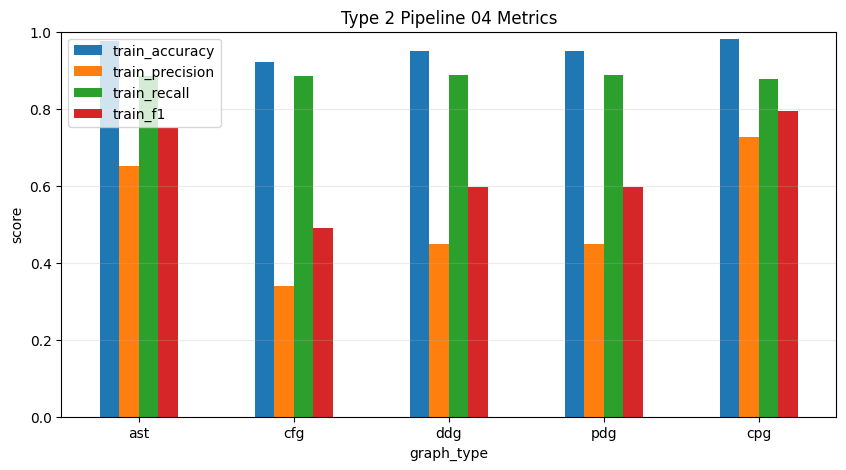

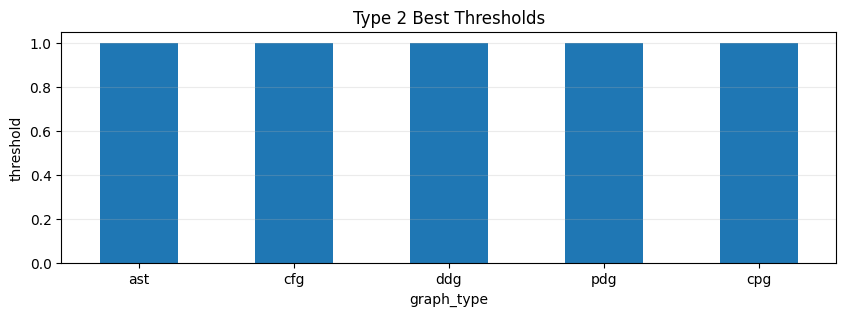

In [5]:
plot_df = df.set_index('graph_type')[['train_accuracy', 'train_precision', 'train_recall', 'train_f1']]
ax = plot_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), rot=0)
ax.set_title(f'Type {BCB_CLONE_TYPE} Pipeline 04 Metrics')
ax.set_ylabel('score')
ax.grid(axis='y', alpha=0.25)
plt.show()

ax = df.set_index('graph_type')['best_threshold'].plot(kind='bar', figsize=(10, 3), rot=0)
ax.set_title(f'Type {BCB_CLONE_TYPE} Best Thresholds')
ax.set_ylabel('threshold')
ax.grid(axis='y', alpha=0.25)
plt.show()


## 5. Timing Stats Snapshot


In [6]:
if TIMING_STATS_PATH.exists():
    timing = json.loads(TIMING_STATS_PATH.read_text(encoding='utf-8'))
    interesting = {
        k: v for k, v in timing.items()
        if k.startswith('total_') or k.startswith('spectral_') or k.startswith('avg_nodes_') or k.startswith('dot_') or k.startswith('skipped_')
    }
    display(pd.DataFrame(list(interesting.items()), columns=['metric', 'value']))
else:
    print(f'Timing stats not found: {TIMING_STATS_PATH}')


,metric,value
0,total_raw_extraction_time,9709.315735
1,total_methods,191650
2,skipped_methods_pipeline01,82
3,skipped_methods_file,C:\Users\koush\PyProjects\outputs\type2\skippe...
4,dot_mapped_ast,186570
5,dot_missing_ast,5080
6,dot_mapped_cfg,186569
7,dot_missing_cfg,5081
8,dot_mapped_ddg,186569
9,dot_missing_ddg,5081
